# NASA Analytics 2010-2024
Deep learning models for NASA launch and budget data.

## 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load Data

In [2]:
df = pd.read_csv('data/raw/Nasa_Analytics_2010_2024.csv')
print(df.shape)
df.head()

(15, 10)


,Company,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
0,NASA,2010,4,4,0,0,18700,18000,3,100.0
1,NASA,2011,5,5,0,0,18500,17500,3,100.0
2,NASA,2012,4,4,0,0,17700,17000,2,100.0
3,NASA,2013,4,4,0,0,16800,17000,2,100.0
4,NASA,2014,5,5,0,0,17600,17200,2,100.0


## 3. Basic Data Check

In [3]:
df.describe().round(2)

,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
count,15.00,15.00,15.00,15.0,15.0,15.00,15.00,15.00,15.0
mean,2017.00,7.07,7.07,0.0,0.0,20565.67,17900.00,2.73,100.0
std,4.47,2.34,2.34,0.0,0.0,2859.15,656.83,0.70,0.0
min,2010.00,4.00,4.00,0.0,0.0,16800.00,17000.00,2.00,100.0
25%,2013.50,5.00,5.00,0.0,0.0,18255.00,17450.00,2.00,100.0
50%,2017.00,7.00,7.00,0.0,0.0,19500.00,17900.00,3.00,100.0
75%,2020.50,8.50,8.50,0.0,0.0,22950.00,18350.00,3.00,100.0
max,2024.00,11.00,11.00,0.0,0.0,25400.00,19000.00,4.00,100.0


In [4]:
df.isnull().sum()

Company                 0
Year                    0
Launches                0
Successful              0
Failed                  0
Revenue_USD_M           0
Budget_Funding_USD_M    0
Employees               0
Rockets                 0
Success_Rate_%          0
dtype: int64

## 4. Exploratory Data Analysis

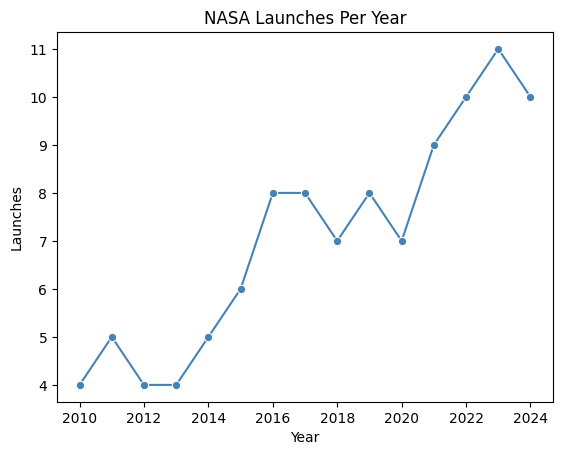

In [5]:
sns.lineplot(data=df, x='Year', y='Launches', marker='o', color='steelblue')
plt.title('NASA Launches Per Year')
plt.show()

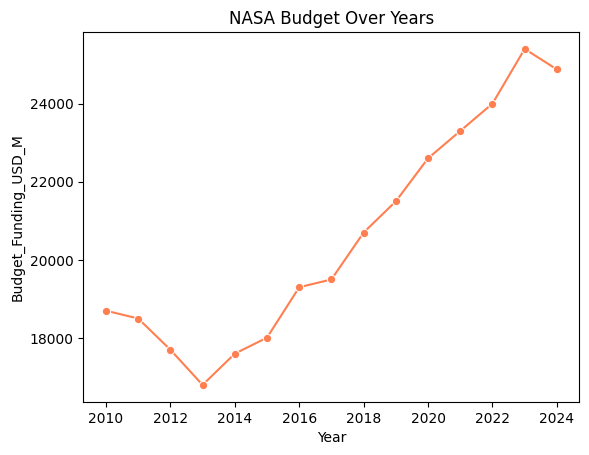

In [6]:
sns.lineplot(data=df, x='Year', y='Budget_Funding_USD_M', marker='o', color='coral')
plt.title('NASA Budget Over Years')
plt.show()

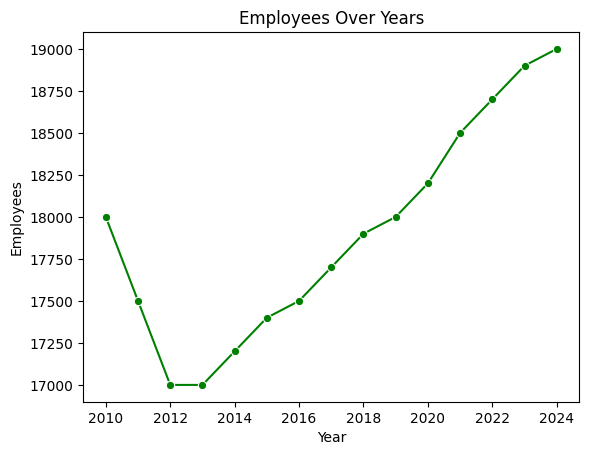

In [7]:
sns.lineplot(data=df, x='Year', y='Employees', marker='o', color='green')
plt.title('Employees Over Years')
plt.show()

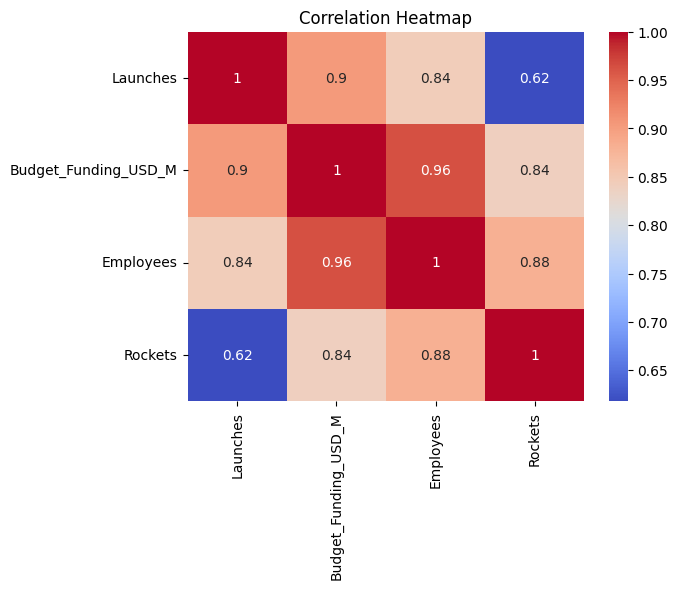

In [8]:
sns.heatmap(df[['Launches','Budget_Funding_USD_M','Employees','Rockets']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

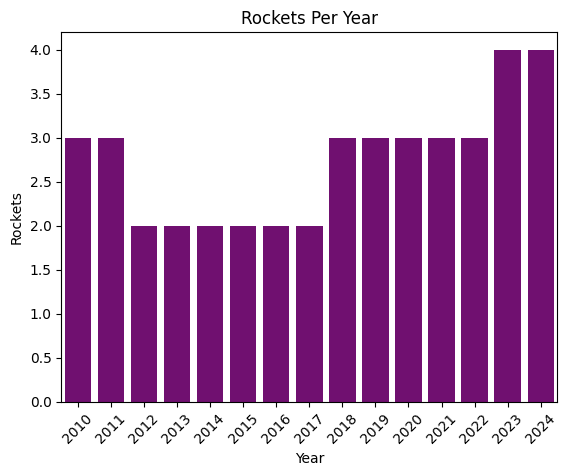

In [9]:
sns.barplot(data=df, x='Year', y='Rockets', color='purple')
plt.title('Rockets Per Year')
plt.xticks(rotation=45)
plt.show()

## 5. Preprocessing

In [10]:
features = ['Launches', 'Employees', 'Rockets', 'Budget_Funding_USD_M']
target   = 'Budget_Funding_USD_M'

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[features])

# Budget is the value I am trying to predict.
target_idx = features.index(target)

## 6. Time Series Sequences

In [11]:
def make_sequences(data, steps=3):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i:i+steps, :])
        y.append(data[i+steps, target_idx])
    return np.array(X), np.array(y)

SEQ = 3
X_seq, y_seq = make_sequences(data_scaled, SEQ)

split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (9, 3, 4) | Test: (3, 3, 4)


## 7. RNN Model

In [12]:
rnn = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(SEQ, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])
rnn.compile(optimizer='adam', loss='mse')
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
es = EarlyStopping(patience=10, restore_best_weights=True)
rnn_hist = rnn.fit(X_train, y_train, epochs=100, batch_size=4,
                   validation_data=(X_test, y_test),
                   callbacks=[es], verbose=0)

rnn_pred = rnn.predict(X_test)
print("RNN  | MAE:", round(mean_absolute_error(y_test, rnn_pred), 4),
      "| R2:", round(r2_score(y_test, rnn_pred), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
RNN  | MAE: 0.0459 | R2: 0.4837


## 8. LSTM Model

In [14]:
lstm = Sequential([
    LSTM(32, activation='tanh', input_shape=(SEQ, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

lstm_hist = lstm.fit(X_train, y_train, epochs=100, batch_size=4,
                     validation_data=(X_test, y_test),
                     callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)

lstm_pred = lstm.predict(X_test)
print("LSTM | MAE:", round(mean_absolute_error(y_test, lstm_pred), 4),
      "| R2:", round(r2_score(y_test, lstm_pred), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
LSTM | MAE: 0.0962 | R2: -1.3987


## 9. GRU Model

In [15]:
gru = Sequential([
    GRU(32, activation='tanh', input_shape=(SEQ, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])
gru.compile(optimizer='adam', loss='mse')

gru_hist = gru.fit(X_train, y_train, epochs=100, batch_size=4,
                   validation_data=(X_test, y_test),
                   callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)

gru_pred = gru.predict(X_test)
print("GRU  | MAE:", round(mean_absolute_error(y_test, gru_pred), 4),
      "| R2:", round(r2_score(y_test, gru_pred), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
GRU  | MAE: 0.0899 | R2: -1.2342


## 10. Loss Curves

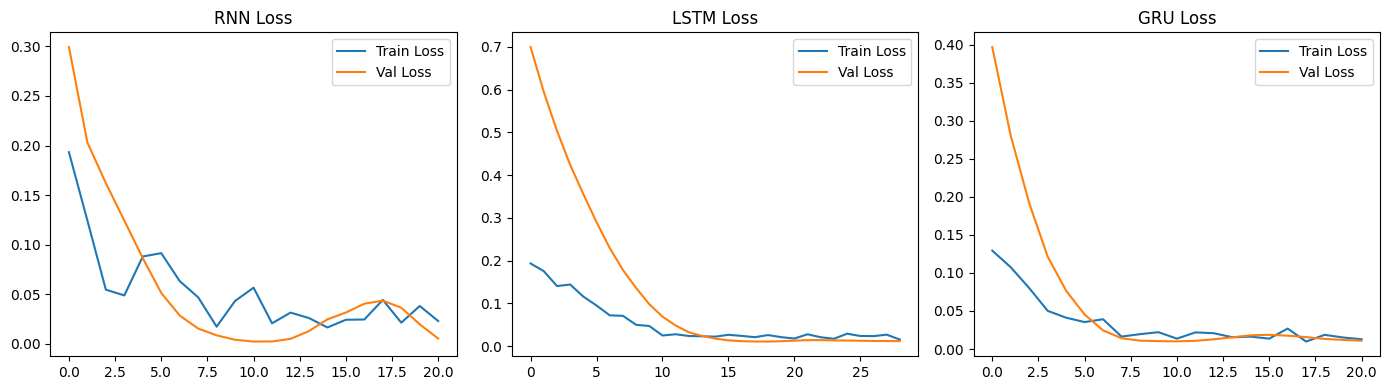

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, hist, name in zip(axes,
                           [rnn_hist, lstm_hist, gru_hist],
                           ['RNN', 'LSTM', 'GRU']):
    ax.plot(hist.history['loss'],     label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(f'{name} Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## 11. Actual vs Predicted

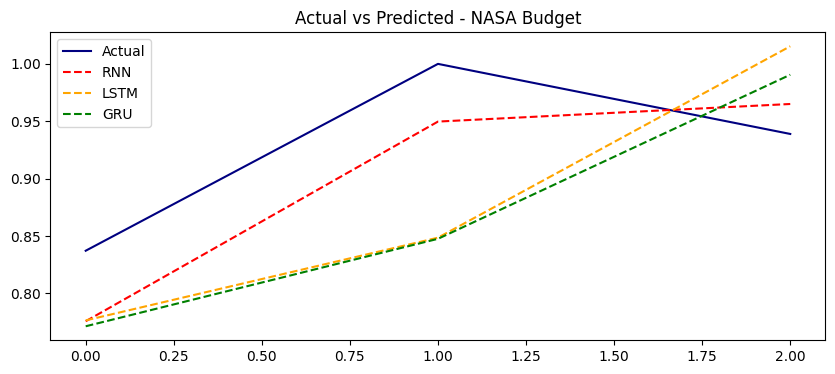

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(y_test, label='Actual', color='navy')
plt.plot(rnn_pred,  label='RNN',  linestyle='--', color='red')
plt.plot(lstm_pred, label='LSTM', linestyle='--', color='orange')
plt.plot(gru_pred,  label='GRU',  linestyle='--', color='green')
plt.title('Actual vs Predicted - NASA Budget')
plt.legend()
plt.show()

## 12. Model Comparison

         MAE      R2
RNN   0.0459  0.4837
LSTM  0.0962 -1.3987
GRU   0.0899 -1.2342


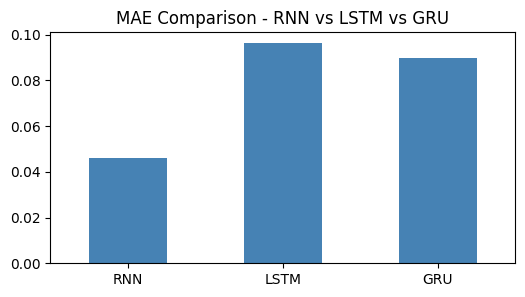

In [18]:
results = {
    'RNN' : {'MAE': mean_absolute_error(y_test, rnn_pred),  'R2': r2_score(y_test, rnn_pred)},
    'LSTM': {'MAE': mean_absolute_error(y_test, lstm_pred), 'R2': r2_score(y_test, lstm_pred)},
    'GRU' : {'MAE': mean_absolute_error(y_test, gru_pred),  'R2': r2_score(y_test, gru_pred)},
}

summary = pd.DataFrame(results).T.round(4)
print(summary)

summary['MAE'].plot(kind='bar', color='steelblue', figsize=(6,3))
plt.title('MAE Comparison - RNN vs LSTM vs GRU')
plt.xticks(rotation=0)
plt.show()

## 13. Save Models

In [19]:
rnn.save('rnn_nasa.h5')
lstm.save('lstm_nasa.h5')
gru.save('gru_nasa.h5')
print("Models saved.")

Models saved.


## 14. Conclusion

In this notebook, I used RNN, LSTM, and GRU models to predict NASA budget values using the available yearly data. The models run successfully, but the dataset is very small, so the scores can be weak or negative. This means the predictions are not very strong, but the notebook still shows the full deep learning workflow from loading data to training, comparing, and saving models.